<a href="https://colab.research.google.com/github/Latifmmhd/Augmentasi-Data-Indonesia-Tweet/blob/main/ft_with_peft_augmented_bnf16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip Emotion-classification-with-PEFT_Augmented_bnf16.zip

Archive:  Emotion-classification-with-PEFT_Augmented_bnf16.zip
   creating: Emotion-classification-with-PEFT_Augmented_bnf16/
   creating: Emotion-classification-with-PEFT_Augmented_bnf16/.git/
  inflating: Emotion-classification-with-PEFT_Augmented_bnf16/.git/config  
  inflating: Emotion-classification-with-PEFT_Augmented_bnf16/.git/description  
  inflating: Emotion-classification-with-PEFT_Augmented_bnf16/.git/HEAD  
   creating: Emotion-classification-with-PEFT_Augmented_bnf16/.git/hooks/
  inflating: Emotion-classification-with-PEFT_Augmented_bnf16/.git/hooks/applypatch-msg.sample  
  inflating: Emotion-classification-with-PEFT_Augmented_bnf16/.git/hooks/commit-msg.sample  
  inflating: Emotion-classification-with-PEFT_Augmented_bnf16/.git/hooks/fsmonitor-watchman.sample  
  inflating: Emotion-classification-with-PEFT_Augmented_bnf16/.git/hooks/post-update.sample  
  inflating: Emotion-classification-with-PEFT_Augmented_bnf16/.git/hooks/pre-applypatch.sample  
  inflating: Emotio

In [3]:
%cd Emotion-classification-with-PEFT_Augmented_bnf16

/content/Emotion-classification-with-PEFT_Augmented_bnf16


In [4]:
!pip install -r requirements.txt

  Using cached peft-0.7.2.dev0-py3-none-any.whl


In [1]:
import pandas as pd
import numpy as np
import os
import torch
import time
import json

from peft import LoraConfig, LoraModel, get_peft_model, TaskType
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)

os.environ["TOKENIZERS_PARALLELISM"] = "false"
use_cuda = torch.cuda.is_available()

In [5]:
df = pd.read_csv('dataset/all_data_augmented_bnf16.csv')
train_data = pd.read_csv('dataset/train.csv')
val_data = pd.read_csv('dataset/val.csv')
test_data = pd.read_csv('dataset/test.csv')

# Length train, val, and test
print("Train: ",len(train_data))
print("Val: ",len(val_data))
print("Test: ",len(test_data))

Train:  8820
Val:  1890
Test:  1890


In [6]:
tags = np.unique(df['label'])
num_labels = len(tags)
max_length = 128
label2id = {t: i for i, t in enumerate(tags)}
id2label = {i: t for i, t in enumerate(tags)}

In [7]:
def model_init(model_name):
    global tokenizer
    global data_collator
    global tr_model

    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id
    )
    tokenizer = AutoTokenizer.from_pretrained(model_name, model_max_length=128)

    # Configure LoRA
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=8, # Rank of the low-rank matrices
        lora_alpha=32,
        lora_dropout=0.1
    )

    # Wrap the base model with the LoRA configuration
    model = get_peft_model(base_model, lora_config)
    model.print_trainable_parameters()

    return model, tokenizer


def tokenize_function(examples):
    # process the input sequence
    tokenized_input = tokenizer(examples["tweet"],
                                truncation=True,
                                padding='max_length',
                                max_length=max_length)
    # process the labels
    tokenized_input['label'] = [label2id[lb] for lb in examples['label']]

    return tokenized_input


def preprocessing():
    X_train = Dataset.from_pandas(train_data)
    X_val = Dataset.from_pandas(val_data)
    X_test = Dataset.from_pandas(test_data)

    tokenized_train_data = X_train.map(tokenize_function, batched=True)
    tokenized_val_data = X_val.map(tokenize_function, batched=True)
    tokenized_test_data = X_test.map(tokenize_function, batched=True)

    return tokenized_train_data, tokenized_val_data, tokenized_test_data


def compute_metrics(p):
    pred, labels = p
    pred = np.argmax(pred, axis=1)

    true_labels = [tags[l] for l in labels]
    true_predictions = [tags[pr] for pr in pred]

    report = classification_report(true_labels, true_predictions, digits=4)
    acc = accuracy_score(y_true=true_labels, y_pred=true_predictions)
    rec = recall_score(y_true=true_labels, y_pred=true_predictions, average="macro")
    prec = precision_score(y_true=true_labels, y_pred=true_predictions, average="macro")
    f1 = f1_score(y_true=true_labels, y_pred=true_predictions, average="macro", zero_division=1.0)

    print("Classification Report:\n{}".format(report))
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

In [8]:
# to generate the confusion matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def generate_confusion_matrix(true_labels, pred_labels, num_labels):
    cm = confusion_matrix(true_labels, pred_labels)
    labels = [id2label[i] for i in range(num_labels)]
    plt.figure(figsize=(8, 6))
    sns.set(font_scale=1.5)
    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=labels,
                yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.yticks(rotation=0)
    plt.show()

In [9]:
def train_model(model_name, output_dir, learning_rate, train_batch_size, eval_batch_size, num_epochs, weight_decay):

    model, tokenizer = model_init(model_name)
    train_tokenized, val_tokenized, test_tokenized = preprocessing()

    training_args = TrainingArguments(
        output_dir=output_dir,
        logging_strategy="epoch",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit = 1,
        learning_rate=learning_rate,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=train_batch_size,
        per_device_eval_batch_size=eval_batch_size,
        weight_decay=weight_decay,
        load_best_model_at_end=True,
        #push_to_hub=True, # to push to hub during the training
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    trainer.save_model(output_dir)
    #trainer.push_to_hub(commit_message="Training complete")

    # Get the evaluation results
    trainer.eval_dataset=test_tokenized
    evaluation_results = trainer.evaluate()
    print(evaluation_results)

    # make prediction on the test set
    predictions = trainer.predict(test_tokenized)
    pred_labels = np.argmax(predictions.predictions, axis=1)
    true_labels = test_tokenized["label"]

    # Generate confusion matrix
    generate_confusion_matrix(true_labels, pred_labels, num_labels)

    return trainer

In [10]:

def show_log_history(trainer):
    log_history = pd.DataFrame(trainer.state.log_history)
    log_history = log_history.fillna(0)
    log_history = log_history.groupby(["epoch"]).sum()

    log_history[["loss", "eval_loss"]].plot()
    plt.show()

In [11]:
def main(model_name, output_dir, best_params):
    start = time.time()
     # load json file containing best params
    best_params = best_params

    with open(best_params, 'r') as js:
        data = json.load(js)

    print(data)

    # define best params
    num_train_epochs = data['num_train_epochs']
    learning_rate = data['learning_rate']
    train_batch_size = data['per_device_train_batch_size']
    eval_batch_size = data['per_device_eval_batch_size']
    weight_decay = data['weight_decay']

    # training
    tr_model = train_model(model_name=model_name,
                           output_dir=output_dir,
                           learning_rate=learning_rate,
                           train_batch_size=train_batch_size,
                           eval_batch_size=eval_batch_size,
                           num_epochs=num_train_epochs,
                           weight_decay=weight_decay)

    print('Training finished!')

    show_log_history(tr_model)


    end = time.time()
    exec_time = (end - start) / 60
    print(f'Total time: {exec_time} minutes')

{'num_train_epochs': 3, 'learning_rate': 0.0003, 'per_device_train_batch_size': 16, 'per_device_eval_batch_size': 32, 'weight_decay': 0.04209249762875744}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 299,526 || all params: 110,862,348 || trainable%: 0.27017829353569167


Map:   0%|          | 0/8820 [00:00<?, ? examples/s]

Map:   0%|          | 0/1890 [00:00<?, ? examples/s]

...

wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 21523190 (21523190-universitas-islam-indonesia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.871000,0.709881,0.766138,0.769019,0.770993,0.761739
2,0.588800,0.664463,0.771429,0.770484,0.776051,0.768030
3,0.510500,0.631795,0.789947,0.789008,0.793386,0.789620


Classification Report:
              precision    recall  f1-score   support

       anger     0.7071    0.8758    0.7825       306
        fear     0.7908    0.8674    0.8274       279
         joy     0.7658    0.7311    0.7481       331
        love     0.7642    0.8762    0.8164       307
     neutral     0.7843    0.4878    0.6015       328
         sad     0.8018    0.7876    0.7946       339

    accuracy                         0.7661      1890
   macro avg     0.7690    0.7710    0.7617      1890
weighted avg     0.7694    0.7661    0.7594      1890

Classification Report:
              precision    recall  f1-score   support

       anger     0.7567    0.8333    0.7932       306
        fear     0.7685    0.8925    0.8259       279
         joy     0.7814    0.7341    0.7570       331
        love     0.7695    0.8697    0.8165       307
     neutral     0.7533    0.5213    0.6162       328
         sad     0.7936    0.8053    0.7994       339

    accuracy                   

Classification Report:
              precision    recall  f1-score   support

       anger     0.8196    0.8481    0.8336       316
        fear     0.8555    0.8709    0.8631       333
         joy     0.8019    0.7994    0.8006       319
        love     0.8323    0.8904    0.8604       301
     neutral     0.7860    0.5932    0.6761       322
         sad     0.7155    0.8161    0.7625       299

    accuracy                         0.8021      1890
   macro avg     0.8018    0.8030    0.7994      1890
weighted avg     0.8028    0.8021    0.7994      1890

{'eval_loss': 0.6162323355674744, 'eval_accuracy': 0.8021164021164021, 'eval_precision': 0.8017941290212786, 'eval_recall': 0.802988639920005, 'eval_f1': 0.7993791735464776, 'eval_runtime': 3.5641, 'eval_samples_per_second': 530.282, 'eval_steps_per_second': 16.834, 'epoch': 3.0}
Classification Report:
              precision    recall  f1-score   support

       anger     0.8196    0.8481    0.8336       316
        fear     0.85

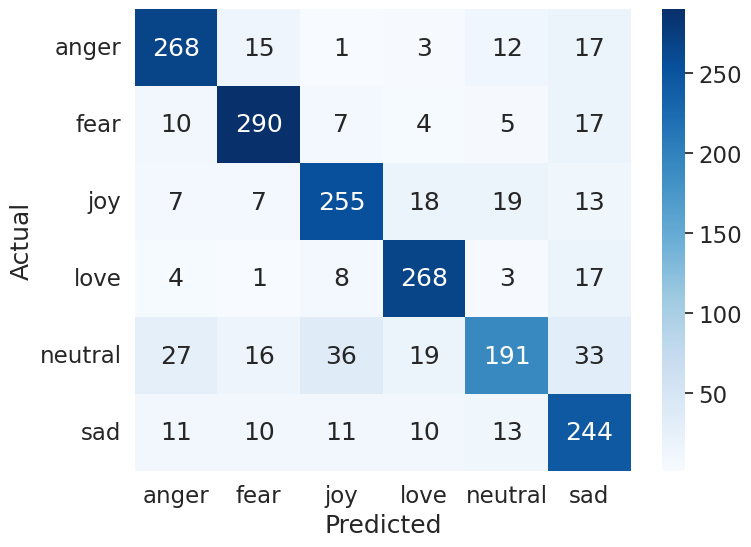

Training finished!


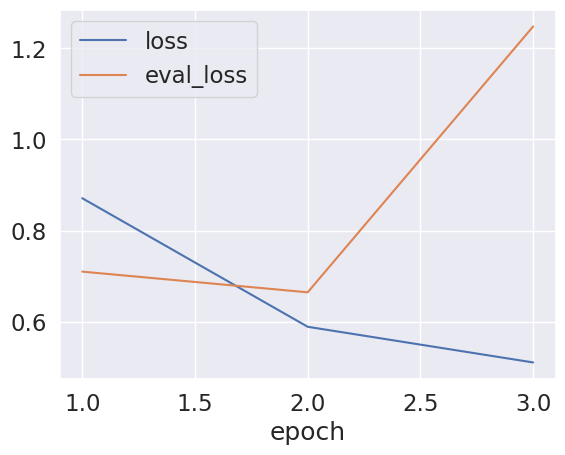

Total time: 2.7714873711268107 minutes


In [12]:
#1 IndoBERTweet peft

main(
    model_name = 'indolem/indobertweet-base-uncased',
    output_dir = 'p-emotcls-indobertweet-base',
    best_params = 'best_params/p-indobertweet.json'
)

{'num_train_epochs': 7, 'learning_rate': 0.0001, 'per_device_train_batch_size': 8, 'per_device_eval_batch_size': 8, 'weight_decay': 0.09961791911316853}


config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

Map:   0%|          | 0/1890 [00:00<?, ? examples/s]

Map:   0%|          | 0/1890 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.995300,0.799119,0.762434,0.765585,0.767637,0.755828
2,0.643300,0.698396,0.773016,0.773624,0.776480,0.772103
3,0.591100,0.668748,0.773016,0.773400,0.775684,0.772058
4,0.533700,0.672313,0.790476,0.789866,0.793541,0.788836
5,0.503700,0.694687,0.791534,0.792565,0.794358,0.788997
6,0.470500,0.673259,0.795238,0.794634,0.797581,0.794179
7,0.439400,0.688385,0.797354,0.797317,0.800531,0.795742


Classification Report:
              precision    recall  f1-score   support

       anger     0.7120    0.8562    0.7774       306
        fear     0.7433    0.8925    0.8111       279
         joy     0.7710    0.7221    0.7457       331
        love     0.7739    0.8697    0.8190       307
     neutral     0.7957    0.4512    0.5759       328
         sad     0.7977    0.8142    0.8058       339

    accuracy                         0.7624      1890
   macro avg     0.7656    0.7676    0.7558      1890
weighted avg     0.7669    0.7624    0.7537      1890

Classification Report:
              precision    recall  f1-score   support

       anger     0.7361    0.8203    0.7759       306
        fear     0.8123    0.8530    0.8322       279
         joy     0.7463    0.7644    0.7552       331
        love     0.7659    0.8632    0.8116       307
     neutral     0.7510    0.5793    0.6540       328
         sad     0.8302    0.7788    0.8037       339

    accuracy                   

Classification Report:
              precision    recall  f1-score   support

       anger     0.8662    0.7373    0.7966       316
        fear     0.7803    0.9279    0.8477       333
         joy     0.8333    0.8307    0.8320       319
        love     0.8522    0.9003    0.8756       301
     neutral     0.7286    0.6335    0.6777       322
         sad     0.7767    0.8027    0.7895       299

    accuracy                         0.8053      1890
   macro avg     0.8062    0.8054    0.8032      1890
weighted avg     0.8057    0.8053    0.8028      1890

{'eval_loss': 0.6112349629402161, 'eval_accuracy': 0.8052910052910053, 'eval_precision': 0.8062131804855187, 'eval_recall': 0.8054231478472221, 'eval_f1': 0.8031938839441488, 'eval_runtime': 12.0566, 'eval_samples_per_second': 156.761, 'eval_steps_per_second': 19.657, 'epoch': 7.0}
Classification Report:
              precision    recall  f1-score   support

       anger     0.8662    0.7373    0.7966       316
        fear     0.

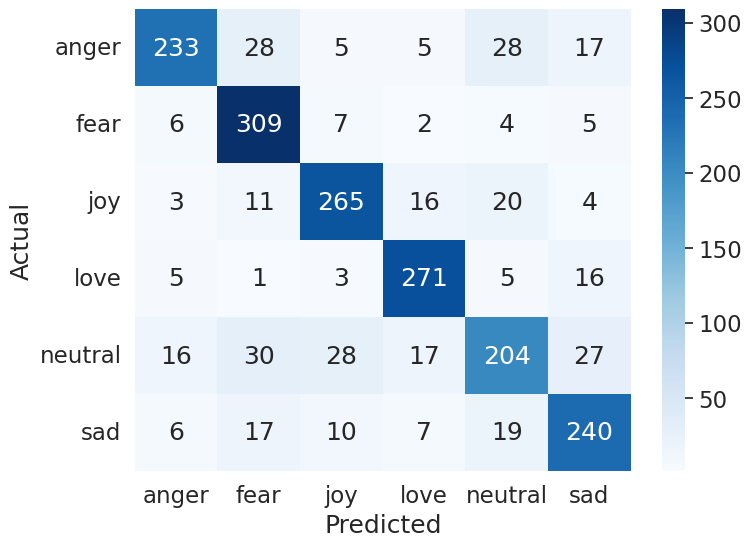

Training finished!


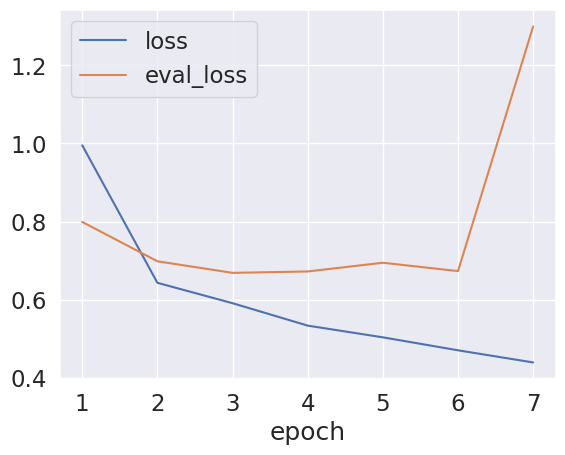

Total time: 16.326829540729523 minutes


In [13]:
#2 FacebookAI/xlm-roberta-large peft

main(
    model_name = 'FacebookAI/xlm-roberta-large',
    output_dir = 'p-emotcls-xlm-r-large',
    best_params = 'best_params/p-xlm-r-large.json'
)

{'num_train_epochs': 9, 'learning_rate': 0.0003, 'per_device_train_batch_size': 8, 'per_device_eval_batch_size': 64, 'weight_decay': 0.06192251448466696}


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

Map:   0%|          | 0/1890 [00:00<?, ? examples/s]

Map:   0%|          | 0/1890 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.020800,0.961229,0.714815,0.735981,0.721352,0.699533
2,0.724100,0.727915,0.768783,0.769926,0.771960,0.768465
3,0.640200,0.758520,0.751323,0.755901,0.754133,0.746586
4,0.578400,0.775317,0.756085,0.764416,0.760699,0.748054
5,0.520100,0.730471,0.782540,0.784596,0.784651,0.779610
6,0.474500,0.784779,0.781481,0.781447,0.784663,0.779084
7,0.436600,0.814759,0.775132,0.778247,0.776851,0.774761
8,0.404700,0.821185,0.787302,0.788281,0.790373,0.784844
9,0.375500,0.838295,0.788360,0.787776,0.791061,0.787003


Classification Report:
              precision    recall  f1-score   support

       anger     0.6608    0.7320    0.6946       306
        fear     0.6580    0.9104    0.7639       279
         joy     0.7097    0.7311    0.7202       331
        love     0.7207    0.8827    0.7936       307
     neutral     0.8929    0.3049    0.4545       328
         sad     0.7738    0.7670    0.7704       339

    accuracy                         0.7148      1890
   macro avg     0.7360    0.7214    0.6995      1890
weighted avg     0.7392    0.7148    0.6973      1890

Classification Report:
              precision    recall  f1-score   support

       anger     0.7372    0.7516    0.7443       306
        fear     0.8095    0.8530    0.8307       279
         joy     0.7550    0.7915    0.7729       331
        love     0.7431    0.8762    0.8042       307
     neutral     0.7436    0.6189    0.6755       328
         sad     0.8311    0.7404    0.7832       339

    accuracy                   

Classification Report:
              precision    recall  f1-score   support

       anger     0.7815    0.7468    0.7638       316
        fear     0.8419    0.8318    0.8369       333
         joy     0.7958    0.8307    0.8129       319
        love     0.7778    0.9302    0.8472       301
     neutral     0.7249    0.6056    0.6599       322
         sad     0.7643    0.7592    0.7617       299

    accuracy                         0.7831      1890
   macro avg     0.7810    0.7841    0.7804      1890
weighted avg     0.7816    0.7831    0.7802      1890

{'eval_loss': 0.682030975818634, 'eval_accuracy': 0.783068783068783, 'eval_precision': 0.7810321072460912, 'eval_recall': 0.7840680371117758, 'eval_f1': 0.780390023470053, 'eval_runtime': 3.2519, 'eval_samples_per_second': 581.207, 'eval_steps_per_second': 9.226, 'epoch': 9.0}
Classification Report:
              precision    recall  f1-score   support

       anger     0.7815    0.7468    0.7638       316
        fear     0.8419 

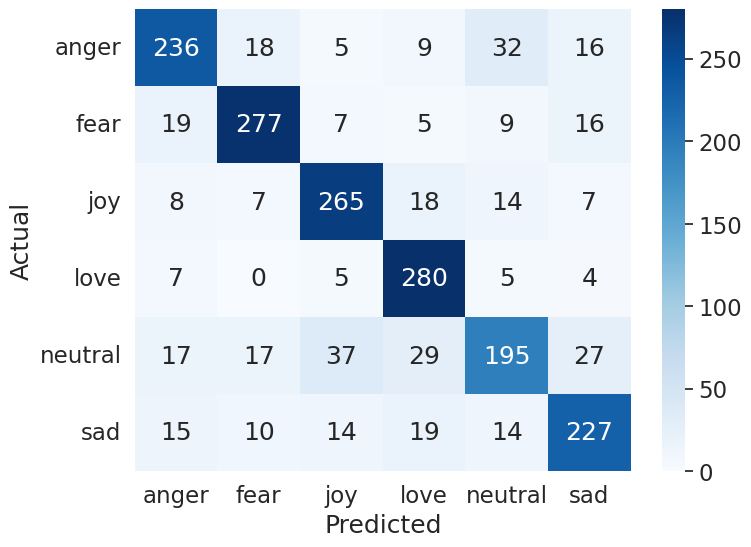

Training finished!


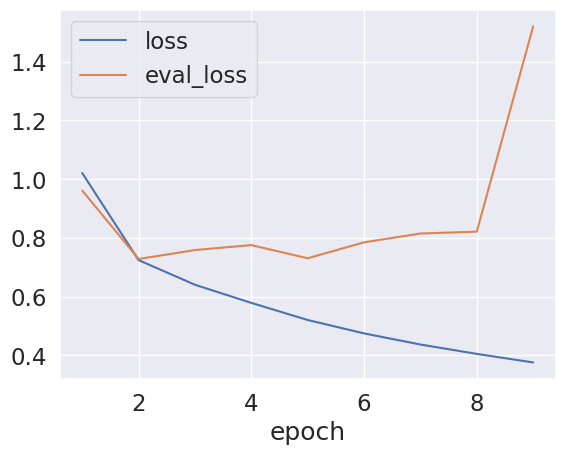

Total time: 8.80844168663025 minutes


In [14]:
#3 FacebookAI/xlm-roberta-base peft

main(
    model_name = 'FacebookAI/xlm-roberta-base',
    output_dir = 'p-emotcls-xlm-r-base',
    best_params = 'best_params/p-xlm-r-base.json'
)

{'num_train_epochs': 7, 'learning_rate': 0.0001, 'per_device_train_batch_size': 8, 'per_device_eval_batch_size': 8, 'weight_decay': 0.09662786467730278}


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

...

Map:   0%|          | 0/1890 [00:00<?, ? examples/s]

Map:   0%|          | 0/1890 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.513000,1.250860,0.535979,0.525439,0.541021,0.518754
2,1.067500,1.095542,0.628042,0.645602,0.634540,0.625104
3,0.910800,0.997637,0.671429,0.668623,0.676036,0.668786
4,0.829700,0.990367,0.680423,0.677865,0.685737,0.675263
5,0.775900,0.931545,0.697884,0.699443,0.702884,0.695870
6,0.736100,0.922955,0.698942,0.697539,0.703312,0.697472
7,0.712400,0.924154,0.696825,0.695789,0.701440,0.695181


Classification Report:
              precision    recall  f1-score   support

       anger     0.3422    0.2092    0.2596       306
        fear     0.4632    0.6989    0.5571       279
         joy     0.7169    0.5891    0.6468       331
        love     0.6031    0.8860    0.7177       307
     neutral     0.5124    0.5030    0.5077       328
         sad     0.5148    0.3599    0.4236       339

    accuracy                         0.5360      1890
   macro avg     0.5254    0.5410    0.5188      1890
weighted avg     0.5286    0.5360    0.5182      1890

Classification Report:
              precision    recall  f1-score   support

       anger     0.4205    0.5621    0.4811       306
        fear     0.6353    0.7993    0.7079       279
         joy     0.7708    0.5891    0.6678       331
        love     0.6601    0.8795    0.7542       307
     neutral     0.6632    0.3902    0.4914       328
         sad     0.7236    0.5870    0.6482       339

    accuracy                   

Classification Report:
              precision    recall  f1-score   support

       anger     0.6484    0.6361    0.6422       316
        fear     0.7847    0.7988    0.7917       333
         joy     0.7729    0.7680    0.7704       319
        love     0.7585    0.8870    0.8178       301
     neutral     0.6836    0.5435    0.6055       322
         sad     0.6551    0.6923    0.6732       299

    accuracy                         0.7201      1890
   macro avg     0.7172    0.7210    0.7168      1890
weighted avg     0.7180    0.7201    0.7168      1890

{'eval_loss': 0.8399413824081421, 'eval_accuracy': 0.7201058201058201, 'eval_precision': 0.717183049101397, 'eval_recall': 0.7209548281803037, 'eval_f1': 0.7167917785797346, 'eval_runtime': 4.3581, 'eval_samples_per_second': 433.672, 'eval_steps_per_second': 54.381, 'epoch': 7.0}
Classification Report:
              precision    recall  f1-score   support

       anger     0.6484    0.6361    0.6422       316
        fear     0.78

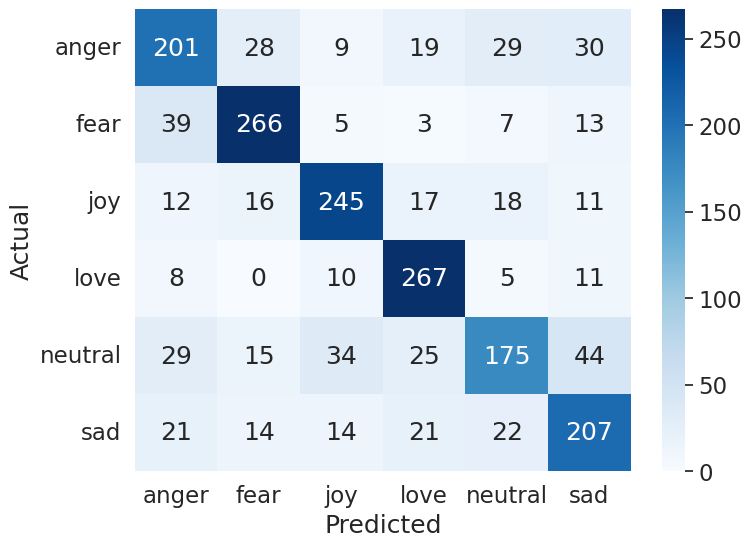

Training finished!


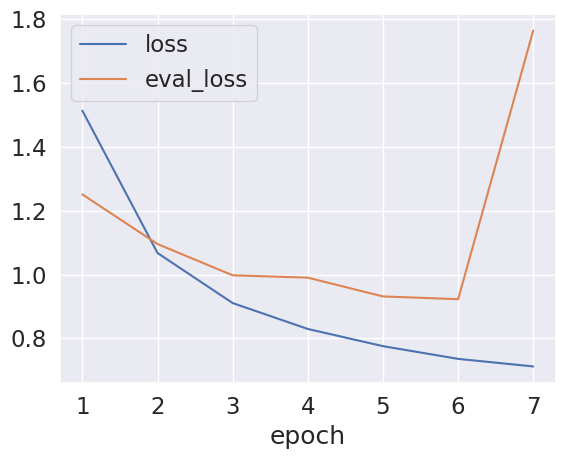

Total time: 6.892911672592163 minutes


In [15]:
#4 google-bert/bert-base-multilingual-cased peft

main(
    model_name = 'google-bert/bert-base-multilingual-cased',
    output_dir = 'p-emotcls-bert-base',
    best_params = 'best_params/p-mbert.json'
)

In [18]:
%cd content/

/content


In [19]:
!zip -r Emotion-classification-with-PEFT_Augmented_bnf16.zip Emotion-classification-with-PEFT_Augmented_bnf16/

  adding: Emotion-classification-with-PEFT_Augmented_bnf16/ (stored 0%)
  adding: Emotion-classification-with-PEFT_Augmented_bnf16/hp_tuning_peft.py (deflated 61%)
  adding: Emotion-classification-with-PEFT_Augmented_bnf16/p-emotcls-xlm-r-base/ (stored 0%)
  adding: Emotion-classification-with-PEFT_Augmented_bnf16/p-emotcls-xlm-r-base/adapter_model.safetensors (deflated 7%)
  adding: Emotion-classification-with-PEFT_Augmented_bnf16/p-emotcls-xlm-r-base/runs/ (stored 0%)
  adding: Emotion-classification-with-PEFT_Augmented_bnf16/p-emotcls-xlm-r-base/runs/Jul20_06-48-25_669a2a1c8a26/ (stored 0%)
  adding: Emotion-classification-with-PEFT_Augmented_bnf16/p-emotcls-xlm-r-base/runs/Jul20_06-48-25_669a2a1c8a26/events.out.tfevents.1784530106.669a2a1c8a26.4021.4 (deflated 62%)
  adding: Emotion-classification-with-PEFT_Augmented_bnf16/p-emotcls-xlm-r-base/runs/Jul20_06-48-25_669a2a1c8a26/events.out.tfevents.1784530618.669a2a1c8a26.4021.5 (deflated 30%)
  adding: Emotion-classification-with-PEF

In [20]:
from google.colab import files
files.download('Emotion-classification-with-PEFT_Augmented_bnf16.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>